# Retailrocket E-commerce Recommendation System

## 0. Setup & Load Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})

# Colour palette
C = {'blue':'#4e79a7','orange':'#f28e2b','red':'#e15759',
     'teal':'#76b7b2','green':'#59a14f','purple':'#b07aa1',
     'yellow':'#edc948','navy':'#1f4e79'}

In [2]:
# Load tất cả raw files bằng DuckDB

con = duckdb.connect()

# events.csv
con.execute("""
    CREATE OR REPLACE TABLE events AS
    SELECT *
    FROM read_csv_auto('data/raw/events.csv')
""")

# item_properties
con.execute("""
    CREATE OR REPLACE TABLE item_properties AS
    SELECT *
    FROM (
        SELECT * FROM read_csv_auto('data/raw/item_properties_part1.csv')
        UNION ALL
        SELECT * FROM read_csv_auto('data/raw/item_properties_part2.csv')
    )
""")

# category_tree
con.execute("""
    CREATE OR REPLACE TABLE category_tree AS
    SELECT * FROM read_csv_auto('data/raw/category_tree.csv')
""")

n_events = con.execute('SELECT COUNT(*) FROM events').fetchone()[0]
n_props  = con.execute('SELECT COUNT(*) FROM item_properties').fetchone()[0]
n_cats   = con.execute('SELECT COUNT(*) FROM category_tree').fetchone()[0]
print(f'events          : {n_events:>10,} rows')
print(f'item_properties : {n_props:>10,} rows')
print(f'category_tree   : {n_cats:>10,} rows')

events          :  2,756,101 rows
item_properties : 20,275,902 rows
category_tree   :      1,669 rows


---
## 1. Dataset Overview

In [3]:
# Kiểm tra schema
print('=== events schema ===')
display(con.execute('DESCRIBE events').df())

print('\n=== item_properties schema ===')
display(con.execute('DESCRIBE item_properties').df())

print('\n=== category_tree events ===')
display(con.execute('DESCRIBE category_tree').df())

=== events schema ===


,column_name,column_type,null,key,default,extra
0,timestamp,BIGINT,YES,None,None,None
1,visitorid,BIGINT,YES,None,None,None
2,event,VARCHAR,YES,None,None,None
3,itemid,BIGINT,YES,None,None,None
4,transactionid,BIGINT,YES,None,None,None



=== item_properties schema ===


,column_name,column_type,null,key,default,extra
0,timestamp,BIGINT,YES,None,None,None
1,itemid,BIGINT,YES,None,None,None
2,property,VARCHAR,YES,None,None,None
3,value,VARCHAR,YES,None,None,None



=== category_tree events ===


,column_name,column_type,null,key,default,extra
0,categoryid,BIGINT,YES,None,None,None
1,parentid,BIGINT,YES,None,None,None


In [4]:
# Cập nhập kiểu dữ liệu cho bảng event
con.execute("""
    CREATE OR REPLACE TABLE stg_events AS
    SELECT 
        to_timestamp(CAST(timestamp AS DOUBLE) / 1000.0) ts,
        visitorid,
        event,
        itemid,
        transactionid
    FROM events
""")

In [5]:
# Cập nhập kiểu dữ liệu cho bảng item_properties
con.execute("""
    CREATE OR REPLACE TABLE stg_item_properties AS
    SELECT 
        to_timestamp(CAST(timestamp AS DOUBLE) / 1000.0) ts,
        itemid,
        property,
        value
    FROM item_properties
""")

In [6]:
# Thống kê tổng quan bảng event
stats_event = con.execute("""
    SELECT
        COUNT(*)                                    AS total_events,
        COUNT(DISTINCT visitorid)                   AS unique_users,
        COUNT(DISTINCT itemid)                      AS unique_items,
        COUNT(DISTINCT event)                       AS unique_event,
        MIN(ts)                                     AS date_start,
        MAX(ts)                                     AS date_end
    FROM stg_events
""").df()

for col, val in stats_event.iloc[0].items():
    print(f'{col:<22} {val}')

total_events           2756101
unique_users           1407580
unique_items           235061
unique_event           3
date_start             2015-05-03 10:00:04.384000+07:00
date_end               2015-09-18 09:59:47.788000+07:00


In [7]:
# Thống kê tổng quan bảng items_properties
stats_items = con.execute("""
    SELECT
        COUNT(*)                                    AS total_events,
        COUNT(DISTINCT itemid)                      AS unique_items,
        COUNT(DISTINCT property)                    AS unique_property,
        MIN(ts)                                     AS date_start,
        MAX(ts)                                     AS date_end
    FROM stg_item_properties
""").df()

for col, val in stats_items.iloc[0].items():
    print(f'{col:<22} {val}')

total_events           20275902
unique_items           417053
unique_property        1104
date_start             2015-05-10 10:00:00+07:00
date_end               2015-09-13 10:00:00+07:00


---
## 2. Phân tích Events

### 2.1 Phân phối loại sự kiện

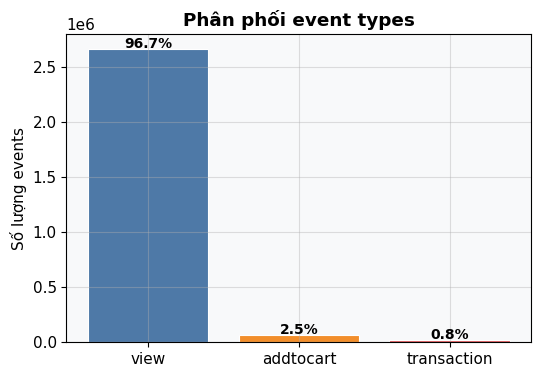

In [9]:
# Event distribution
event_stats = con.execute("""
    SELECT
        event,
        COUNT(*) AS count
    FROM stg_events
    GROUP BY 1
""").df()

# tính toán phần trăm
event_stats["pct"] = (event_stats["count"] / event_stats["count"].sum() * 100).round(1)

# plot
fig, axes = plt.subplots(figsize=(6,4))

palette = [C['blue'], C['orange'], C['red']]

bars = axes.bar(
    event_stats['event'],
    event_stats['count'],
    color=palette,
    edgecolor='white',
    linewidth=0.8
)

for bar, pct in zip(bars, event_stats['pct']):
    axes.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8000,
        f'{pct}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

axes.set_title('Phân phối event types', fontweight='bold')
axes.set_ylabel('Số lượng events')

plt.show()

Retailrocket có % event transaction rất thấp.  

Nếu chỉ dùng `transaction` làm positive, số lượng quá ít để model học hiệu quả. `addtocart` là *strong purchase intent signal* đủ tin cậy để làm nhãn dương. 

Khi đó, ba loại event tương ứng với 3 mức độ ý định mua:

| Event | Label | Ý nghĩa |
|---|---|---|
| `view` | **0 (negative)** | User chỉ xem — chưa có ý định mua rõ ràng |
| `addtocart` | **1 (positive)** | Thêm vào giỏ — purchase intent mạnh |
| `transaction` | **1 (positive)** | Đã mua — tín hiệu mạnh nhất |

### 2.2 Phân phối hoạt động theo thời gian

Temporal pattern quan trọng vì:
1. Cho thấy dataset có mùa vụ không
2. Xác nhận **time-based split** là phù hợp
3. Phát hiện data anomalies (spike/drop bất thường)

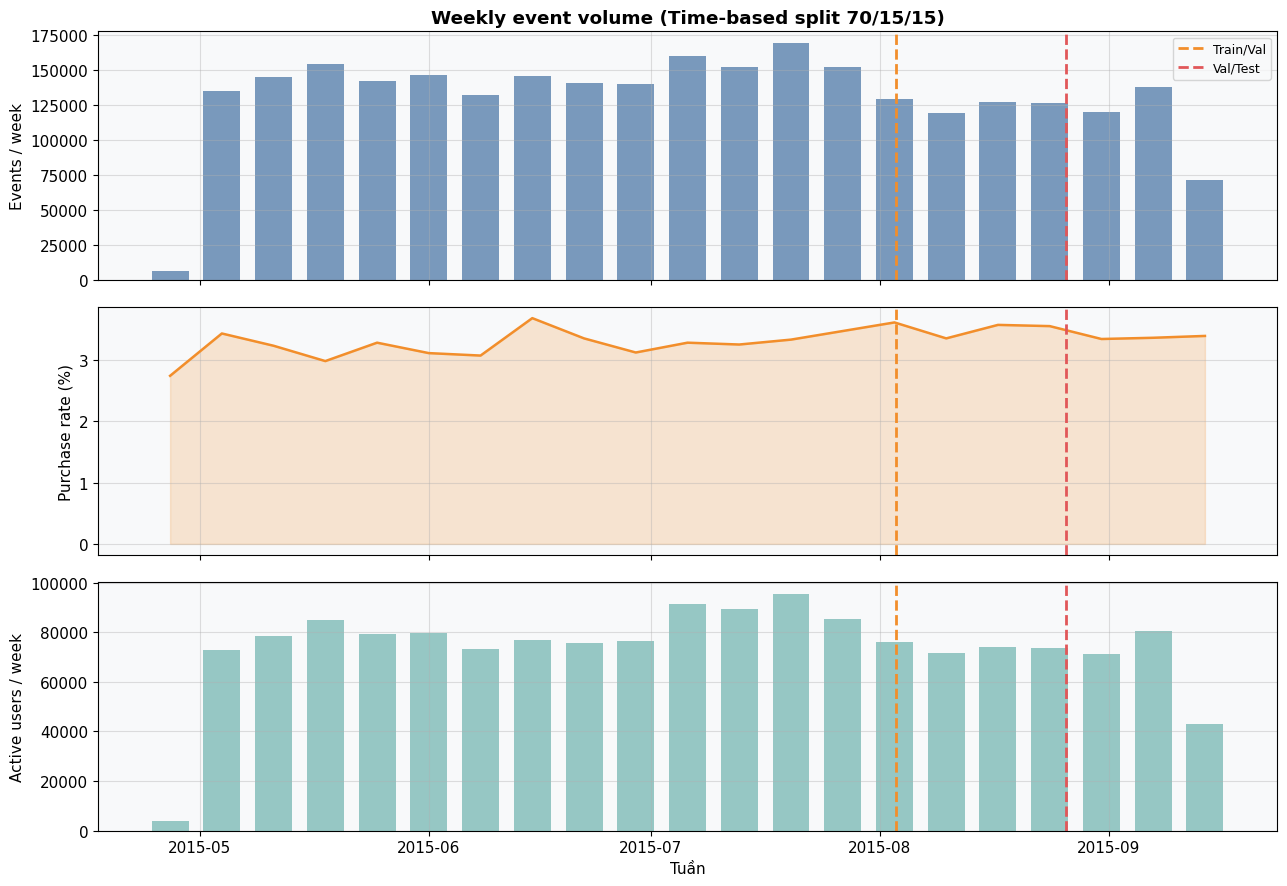

In [10]:
# Weekly activity
weekly = con.execute("""
    SELECT
        DATE_TRUNC('week', ts) AS week,
        COUNT(*) AS total_events,
        SUM(CASE WHEN event IN ('addtocart','transaction') THEN 1 ELSE 0 END) AS purchases,
        ROUND(AVG(CASE WHEN event IN ('addtocart','transaction') THEN 1 ELSE 0 END)*100, 2) AS purchase_rate_pct,
        COUNT(DISTINCT visitorid) AS active_users
    FROM stg_events
    GROUP BY 1 ORDER BY 1
""").df()

# Train/val/test split boundaries (70/15/15 chronological)
all_sorted = con.execute('SELECT ts FROM stg_events ORDER BY ts').df()
n = len(all_sorted)
cut_train = all_sorted.iloc[int(n*0.70)]['ts']
cut_val   = all_sorted.iloc[int(n*0.85)]['ts']

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].bar(weekly['week'], weekly['total_events'], color=C['blue'], alpha=0.75, width=5)
axes[0].axvline(pd.Timestamp(cut_train), color=C['orange'], lw=2, ls='--', label='Train/Val')
axes[0].axvline(pd.Timestamp(cut_val),   color=C['red'],    lw=2, ls='--', label='Val/Test')
axes[0].set_ylabel('Events / week'); axes[0].legend(fontsize=9)
axes[0].set_title('Weekly event volume (Time-based split 70/15/15)', fontweight='bold')

axes[1].plot(weekly['week'], weekly['purchase_rate_pct'], color=C['orange'], lw=1.8)
axes[1].fill_between(weekly['week'], weekly['purchase_rate_pct'], alpha=0.2, color=C['orange'])
axes[1].axvline(pd.Timestamp(cut_train), color=C['orange'], lw=2, ls='--')
axes[1].axvline(pd.Timestamp(cut_val),   color=C['red'],    lw=2, ls='--')
axes[1].set_ylabel('Purchase rate (%)')

axes[2].bar(weekly['week'], weekly['active_users'], color=C['teal'], alpha=0.75, width=5)
axes[2].axvline(pd.Timestamp(cut_train), color=C['orange'], lw=2, ls='--')
axes[2].axvline(pd.Timestamp(cut_val),   color=C['red'],    lw=2, ls='--')
axes[2].set_ylabel('Active users / week'); axes[2].set_xlabel('Tuần')

plt.tight_layout(); plt.show()

---
## 3. Phân tích User Behavior

### 3.1 Activity distribution và Cold User Filter

In [11]:
# User interaction counts
user_stats = con.execute("""
    SELECT
        visitorid,
        COUNT(*) AS n_interactions,
        SUM(CASE WHEN event IN ('addtocart','transaction') THEN 1 ELSE 0 END) AS n_purchases,
        COUNT(DISTINCT itemid) AS unique_items
    FROM stg_events
    GROUP BY visitorid
""").df()

print('=== User activity stats ===')
print(user_stats[['n_interactions','n_purchases','unique_items']].describe([0.25, 0.5, 0.75, 0.9, 0.98]).round(2))

# Cold user filter impact (min_interactions=3)
MIN_N = 3
cold  = (user_stats['n_interactions'] < MIN_N).sum()
total_users = len(user_stats)
print(f'\nTotal unique users: {total_users:,}')
print(f'Cold users (< {MIN_N} events): {cold:,} ({cold/total_users*100:.1f}%) — dropped')
print(f'Remaining users: {total_users-cold:,}')

=== User activity stats ===
       n_interactions  n_purchases  unique_items
count      1407580.00   1407580.00    1407580.00
mean             1.96         0.07          1.52
std             12.58         1.94          7.14
min              1.00         0.00          1.00
25%              1.00         0.00          1.00
50%              1.00         0.00          1.00
75%              2.00         0.00          1.00
90%              3.00         0.00          2.00
98%              9.00         1.00          5.00
max           7757.00      1278.00       3814.00

Total unique users: 1,407,580
Cold users (< 3 events): 1,207,552 (85.8%) — dropped
Remaining users: 200,028


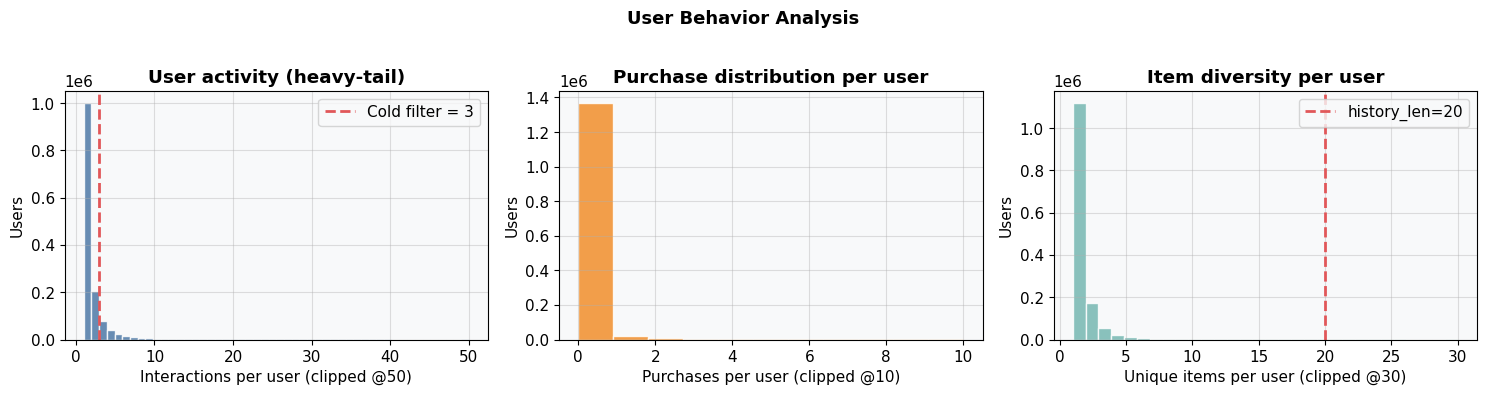

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# n_interactions distribution (log scale)
clipped = user_stats['n_interactions'].clip(upper=50)
axes[0].hist(clipped, bins=50, color=C['blue'], edgecolor='white', alpha=0.85)
axes[0].axvline(MIN_N, color=C['red'], lw=2, ls='--', label=f'Cold filter = {MIN_N}')
axes[0].set_xlabel('Interactions per user (clipped @50)')
axes[0].set_ylabel('Users'); axes[0].legend()
axes[0].set_title('User activity (heavy-tail)', fontweight='bold')

# Purchases per user
pu = user_stats['n_purchases'].clip(upper=10)
axes[1].hist(pu, bins=11, color=C['orange'], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Purchases per user (clipped @10)')
axes[1].set_ylabel('Users')
axes[1].set_title('Purchase distribution per user', fontweight='bold')

# Unique items per user
ui = user_stats['unique_items'].clip(upper=30)
axes[2].hist(ui, bins=30, color=C['teal'], edgecolor='white', alpha=0.85)
axes[2].axvline(20, color=C['red'], lw=2, ls='--', label='history_len=20')
axes[2].set_xlabel('Unique items per user (clipped @30)')
axes[2].set_ylabel('Users'); axes[2].legend()
axes[2].set_title('Item diversity per user', fontweight='bold')

plt.suptitle('User Behavior Analysis', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 4. Phân tích Item

### 4.1 Item Popularity (Power-law distribution)

In [13]:
# Item popularity
item_pop = con.execute("""
    SELECT
        itemid,
        COUNT(*) AS n_interactions,
        SUM(CASE WHEN event IN ('addtocart','transaction') THEN 1 ELSE 0 END) AS n_purchases,
        COUNT(DISTINCT visitorid) AS unique_users
    FROM stg_events
    GROUP BY itemid
    ORDER BY n_interactions DESC
""").df()

total_events = len(con.execute('SELECT * FROM events').df())
top1pct  = int(len(item_pop) * 0.01)
top10pct = int(len(item_pop) * 0.10)

print(f'Total unique items          : {len(item_pop):,}')
print(f'Top 1%  items ({top1pct:,}) → {item_pop.head(top1pct)["n_interactions"].sum()/len(con.execute("SELECT * FROM events").df())*100:.1f}% traffic')
print(f'Top 10% items ({top10pct:,}) → {item_pop.head(top10pct)["n_interactions"].sum()/len(con.execute("SELECT * FROM events").df())*100:.1f}% traffic')
print(f'Median interactions/item    : {item_pop["n_interactions"].median():.0f}')
print(f'Items with 0 purchases      : {(item_pop["n_purchases"]==0).sum():,} ({(item_pop["n_purchases"]==0).mean()*100:.1f}%)')

Total unique items          : 235,061
Top 1%  items (2,350) → 22.9% traffic
Top 10% items (23,506) → 64.0% traffic
Median interactions/item    : 3
Items with 0 purchases      : 210,745 (89.7%)


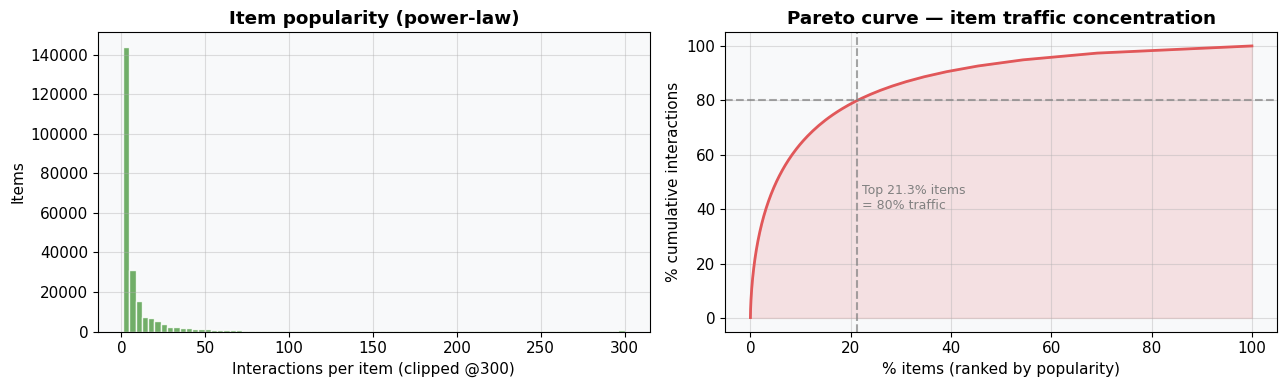

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram popularity
axes[0].hist(item_pop['n_interactions'].clip(upper=300), bins=80,
             color=C['green'], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Interactions per item (clipped @300)')
axes[0].set_ylabel('Items')
axes[0].set_title('Item popularity (power-law)', fontweight='bold')

# Pareto / Lorenz curve
sorted_counts = item_pop['n_interactions'].sort_values(ascending=False)
cum = sorted_counts.cumsum() / sorted_counts.sum()
x   = np.arange(1, len(cum)+1) / len(cum) * 100
axes[1].plot(x, cum.values*100, color=C['red'], lw=2)
axes[1].fill_between(x, cum.values*100, alpha=0.15, color=C['red'])
axes[1].axhline(80, color='gray', ls='--', alpha=0.7)
idx80 = np.searchsorted(cum.values, 0.80)
axes[1].axvline(x[idx80], color='gray', ls='--', alpha=0.7)
axes[1].text(x[idx80]+1, 40, f'Top {x[idx80]:.1f}% items\n= 80% traffic',
             fontsize=9, color='gray')
axes[1].set_xlabel('% items (ranked by popularity)')
axes[1].set_ylabel('% cumulative interactions')
axes[1].set_title('Pareto curve — item traffic concentration', fontweight='bold')

plt.tight_layout(); plt.show()

### 4.2 Item Properties Coverage

In [15]:
# Coverage analysis
coverage = con.execute("""
    SELECT
        COUNT(DISTINCT e.itemid)                               AS items_in_events,
        COUNT(DISTINCT m.itemid)                               AS items_in_props,
        COUNT(DISTINCT CASE WHEN m.itemid IS NOT NULL
                             THEN e.itemid END)                AS items_with_props,
        COUNT(DISTINCT CASE WHEN m.itemid IS NULL
                             THEN e.itemid END)                AS items_missing_props
    FROM (SELECT DISTINCT itemid FROM stg_events) e
    LEFT JOIN stg_item_properties m USING(itemid)
""").df()
display(coverage)

n_total   = coverage['items_in_events'].iloc[0]
n_with    = coverage['items_with_props'].iloc[0]
n_missing = coverage['items_missing_props'].iloc[0]
print(f'\nFeature coverage: {n_with:,}/{n_total:,} = {n_with/n_total*100:.1f}%')
print(f'Items without properties: {n_missing:,} ({n_missing/n_total*100:.1f}%)')

,items_in_events,items_in_props,items_with_props,items_missing_props
0,235061,185246,185246,49815



Feature coverage: 185,246/235,061 = 78.8%
Items without properties: 49,815 (21.2%)


- Không phải tất cả items trong `events.csv` đều có record trong `item_properties`. Chỉ khoảng 79% items có record trong `item_properties`.

In [16]:
# Property types distribution
props_dist = con.execute("""
    SELECT
        property,
        COUNT(DISTINCT itemid) AS n_items,
        COUNT(*) AS n_records,
        MAX((LENGTH(TRIM(value)) - LENGTH(REPLACE(TRIM(value), ' ', '')) + 1)) AS max_value_in_one_snapshot,
        COUNT(DISTINCT value) AS n_value
    FROM stg_item_properties
    GROUP BY property
    ORDER BY n_items DESC, n_records DESC
    LIMIT 15
""").df()

print('=== Top 15 properties by item coverage ===')
display(props_dist)

=== Top 15 properties by item coverage ===


,property,n_items,n_records,max_value_in_one_snapshot,n_value
0,888,417053,3000398,53,454723
1,790,417053,1790516,1,33052
2,available,417053,1503639,1,2
3,categoryid,417053,788214,1,1242
4,283,417053,597419,59,333165
5,364,417053,476486,1,420554
6,112,417053,417053,1,1
7,764,417053,417053,1,1
8,159,417053,417053,1,1
9,678,417019,481966,5,3832


- Theo kết quả thống kê, chỉ có 6 thuộc tính có ở tất cả item và số giá trị lớn hơn 1, nên chúng ta sẽ khám phá 8 thuộc tính này để xem tính phù hợp khi xây dụng vector đại diện cho item.  

- Vì các giá trị của thuộc tính đã mã hoá nên để dễ dàng xử lý, ưu tiên lấy các thuộc tính chỉ có 1 giá trị khi snapshot, khi đó sẽ chỉ còn 3 thuộc tính 790, categoryid, 364 và available. Tuy nhiên các thuộc tính nên tập trung vào thể hiện đặc trưng của sản phẩm, do đó chỉ còn lại 3 thuộc tính 790, categoryid và 364.


In [17]:
# Khám phá thuộc tính 790
con.execute("""
    SELECT *
    FROM stg_item_properties
    WHERE property = '790'
    LIMIT 15
""").df()

,ts,itemid,property,value
0,2015-05-10 10:00:00+07:00,59481,790,n15360.000
1,2015-06-14 10:00:00+07:00,169055,790,n21000.000
2,2015-06-28 10:00:00+07:00,178601,790,n5400.000
3,2015-05-17 10:00:00+07:00,125874,790,n39588.000
4,2015-06-07 10:00:00+07:00,272201,790,n10320.000
5,2015-05-24 10:00:00+07:00,407811,790,n185280.000
6,2015-06-07 10:00:00+07:00,119637,790,n11160.000
7,2015-07-19 10:00:00+07:00,459523,790,n15588.000
8,2015-06-14 10:00:00+07:00,181493,790,n191736.000
9,2015-06-07 10:00:00+07:00,439391,790,n54048.000


Ta nhận thấy thuộc tính 790 là dạng số thực, do đó chúng ta có thể giả định đây là thuộc tính giá (pricing).